In [39]:
import numpy as np
import torch
import torch_geometric.datasets as datasets
import torch_geometric.data as data
import torch_geometric.loader as loader
import torch_geometric.transforms as transforms
import networkx as nx
from torch_geometric.utils.convert import to_networkx

## Data Handling in PyG

### Data

Let's create a dummy graph

In [40]:
embeddings = torch.rand((100, 16), dtype=torch.float)

In [41]:
rows = np.random.choice(100, 500)
cols = np.random.choice(100, 500)
edges = torch.tensor([rows, cols])

In [ ]:
edges_attr = np.random.choice(3, 500)

In [44]:
ys = torch.rand((100)).round().long()

Convert the graph information into a PyG Data object

In [45]:
graph = data.Data(x=embeddings, edge_index=edges, edge_attr=edges_attr, y=ys)

In [46]:
graph

Data(x=[100, 16], edge_index=[2, 500], edge_attr=[500], y=[100])

Let's visualize the information contained in the data object

In [48]:
for prop in graph:
    print(prop)

('x', tensor([[0.8617, 0.4035, 0.2401,  ..., 0.4839, 0.7476, 0.0511],
        [0.0143, 0.1710, 0.6404,  ..., 0.9255, 0.0957, 0.9026],
        [0.8351, 0.8039, 0.2397,  ..., 0.4407, 0.7838, 0.5776],
        ...,
        [0.9057, 0.4458, 0.1079,  ..., 0.4138, 0.5815, 0.6474],
        [0.6843, 0.8596, 0.4841,  ..., 0.3609, 0.1932, 0.4056],
        [0.5537, 0.8659, 0.1162,  ..., 0.8279, 0.0652, 0.0783]]))
('edge_index', tensor([[94, 22, 80, 64, 53, 77,  2, 78, 43,  4, 58, 63, 56, 27,  1, 53, 17, 77,
         77, 10, 67,  3,  5, 58, 97, 14, 39, 22, 55, 49, 82, 73, 74, 10, 57, 33,
         80, 81,  0, 38, 18, 77, 13, 88,  7, 23,  6, 40, 50, 60, 34, 23, 52, 87,
         24, 25, 94, 48, 46, 89, 83, 47, 25, 48, 62, 70, 50, 71, 35, 86, 72, 25,
         87, 33, 54, 19, 24, 49, 70, 46, 91, 28, 67, 82, 14, 25, 78, 71, 74, 88,
         61, 23, 84, 66, 72, 38, 48, 61, 47, 76, 89, 95, 64, 33,  2, 24, 15, 25,
         97, 21, 99, 58, 15, 54, 36,  0, 78, 45, 53, 10, 82, 36, 56, 36, 10, 60,
         10, 

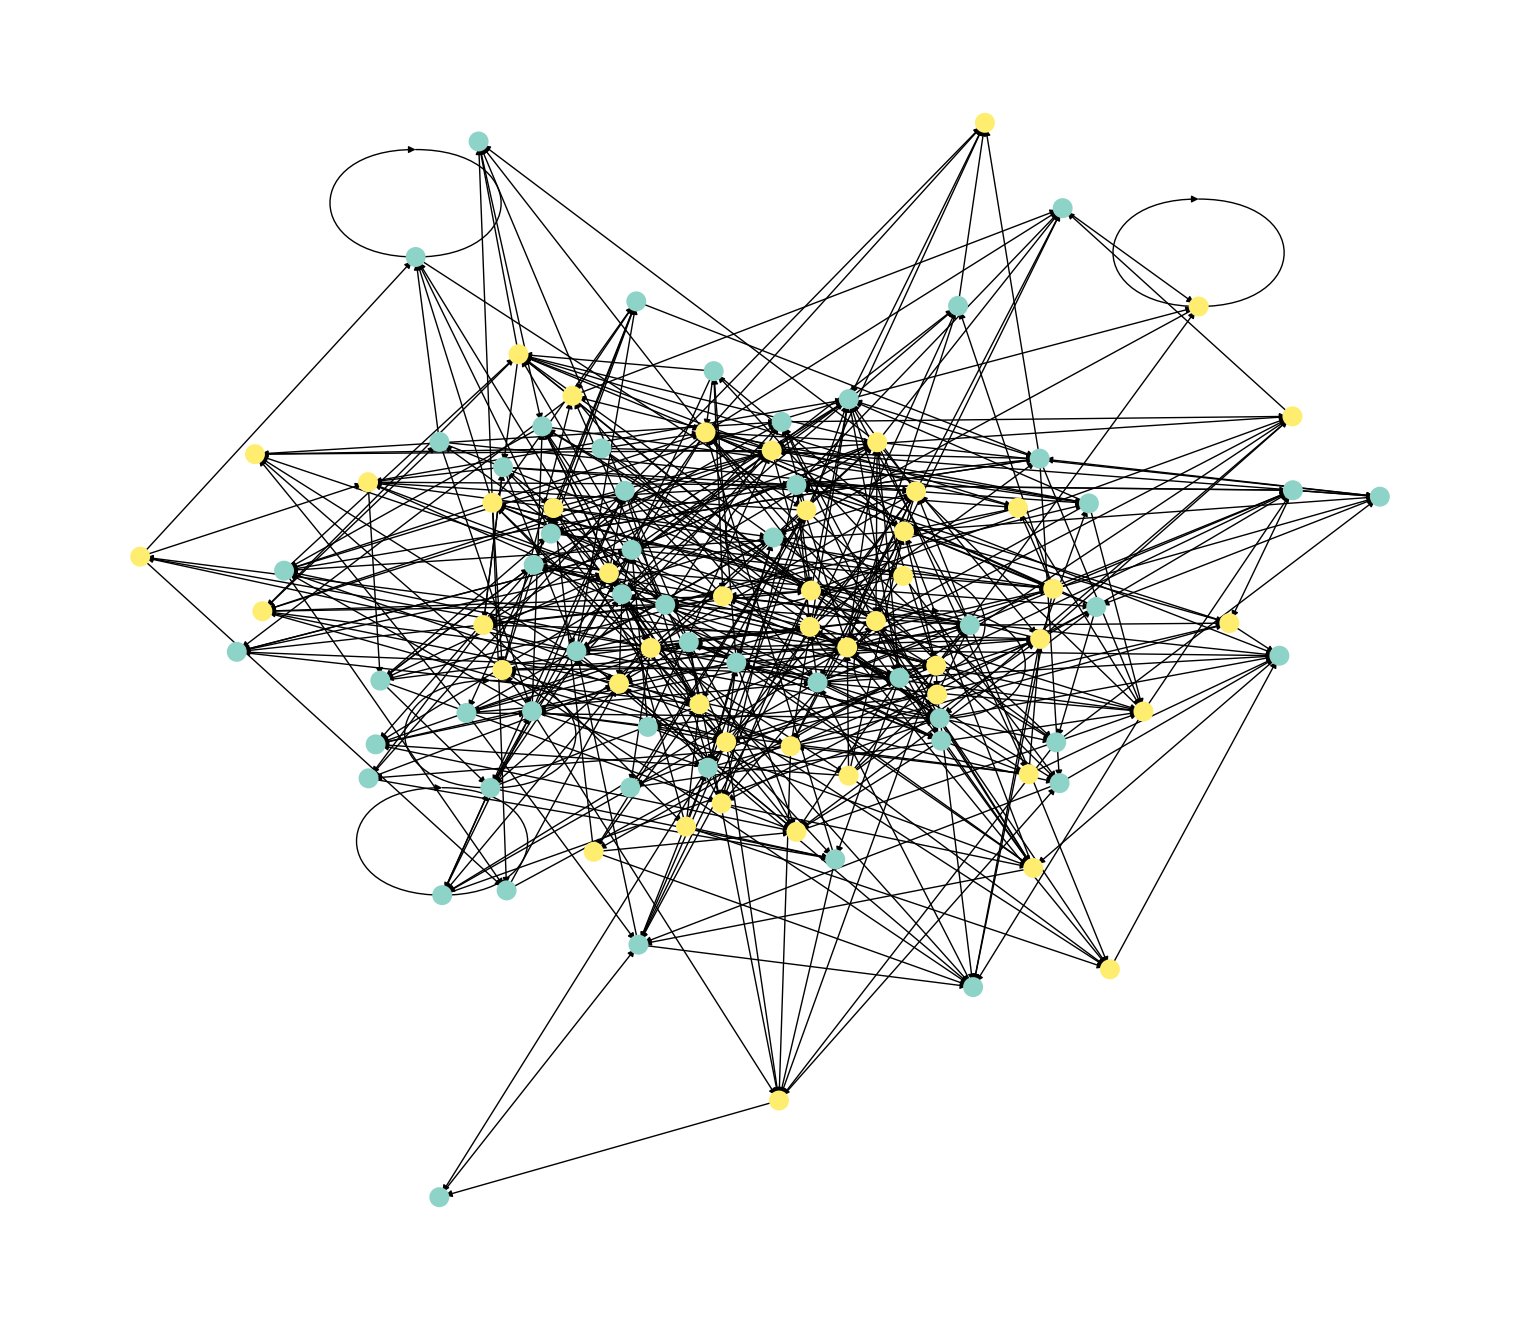

In [ ]:
vis = to_networkx(graph)

node_labels = graph.y.numpy()

import matplotlib.pyplot as plt

plt.figure(1, figsize=(15, 13))
nx.draw(
    vis, cmap=plt.get_cmap('Set3'), node_color=node_labels, node_size=70, linewidths=6
)
plt.show()

### Batch

With the Batch object we can represent multiple graphs as a single disconnected graph

In [50]:
batch = data.Batch().from_data_list([graph, graph])

In [ ]:
print('Number of graphs:', batch.num_graphs)
print('Graph at index 1:', batch[1])
print('Retrieve the list of graphs:\n', len(batch.to_data_list()))

Number of graphs: 2
Graph at index 1: Data(x=[100, 16], edge_index=[2, 500], edge_attr=[500], y=[100])
Retrieve the list of graphs:
 2


### Cluster

ClusterData groups the nodes of a graph into a specific number of cluster for faster computation in large graphs, then use ClusterLoader to load batches of clusters

In [ ]:
# cluster = data.ClusterData(graph, 5)

In [ ]:
# clusterloader = data.ClusterLoader(cluster)

### Sampler

For each convolutional layer, sample a maximum of nodes from each neighborhood (as in GraphSAGE)

In [ ]:
sampler = loader.NeighborSampler(
    graph.edge_index,
    sizes=[3, 10],
    batch_size=4,
    shuffle=False,
)

In [54]:
for s in sampler:
    print(s)
    break

(4, tensor([ 0,  1,  2,  3, 45, 77,  8, 51, 48, 13, 87, 34, 85, 64, 23, 79, 20, 91,
        88, 73, 60, 86, 72, 66, 65, 70, 26, 25, 14, 10,  7, 84, 67, 54, 22, 21,
         5, 82, 49, 29, 27,  6, 61, 12, 93, 95, 24, 15, 33, 52, 16]), [EdgeIndex(edge_index=tensor([[ 4,  5,  6, 15, 16,  7,  8,  9,  5, 10, 11, 17, 12, 13, 14, 18, 18, 19,
         20, 21, 22, 23, 24, 15, 25, 26, 27, 28, 29, 30, 11, 15, 23, 31, 32, 33,
         34, 35, 36,  0,  0, 25, 37, 38, 39, 40, 41, 11, 27, 42, 43,  3, 29, 33,
          2, 32, 44, 14, 21, 33, 38, 45, 46, 47, 28, 32, 36, 48, 13, 16, 28, 33,
         49, 50, 29],
        [ 0,  0,  0,  0,  0,  1,  1,  1,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3,
          3,  4,  4,  4,  4,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,
          6,  6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  9,  9,  9,
         10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 13, 13, 13, 13,
         13, 13, 14]]), e_id=tensor([400,  17, 131, 295, 426, 446, 172,  4

In [ ]:
print('Batch size:', s[0])
print('Number of unique nodes involved in the sampling:', len(s[1]))
print(
    'Number of neighbors sampled:',
    len(s[2][0].edge_index[0]),
    len(s[2][1].edge_index[0]),
)

Batch size: 4
Number of unique nodes involved in the sampling: 51
Number of neighbors sampled: 75 12


### Datasets

List all the available datasets

In [55]:
datasets.__all__

['KarateClub',
 'TUDataset',
 'GNNBenchmarkDataset',
 'Planetoid',
 'NELL',
 'CitationFull',
 'CoraFull',
 'Coauthor',
 'Amazon',
 'PPI',
 'Reddit',
 'Reddit2',
 'Flickr',
 'Yelp',
 'AmazonProducts',
 'QM7b',
 'QM9',
 'MD17',
 'ZINC',
 'AQSOL',
 'MoleculeNet',
 'PCQM4Mv2',
 'Entities',
 'RelLinkPredDataset',
 'GEDDataset',
 'AttributedGraphDataset',
 'MNISTSuperpixels',
 'FAUST',
 'DynamicFAUST',
 'ShapeNet',
 'ModelNet',
 'CoMA',
 'SHREC2016',
 'TOSCA',
 'PCPNetDataset',
 'S3DIS',
 'GeometricShapes',
 'BitcoinOTC',
 'GDELTLite',
 'ICEWS18',
 'GDELT',
 'WILLOWObjectClass',
 'PascalVOCKeypoints',
 'PascalPF',
 'SNAPDataset',
 'SuiteSparseMatrixCollection',
 'WordNet18',
 'WordNet18RR',
 'FB15k_237',
 'WikiCS',
 'WebKB',
 'WikipediaNetwork',
 'HeterophilousGraphDataset',
 'Actor',
 'UPFD',
 'GitHub',
 'FacebookPagePage',
 'LastFMAsia',
 'DeezerEurope',
 'GemsecDeezer',
 'Twitch',
 'Airports',
 'LRGBDataset',
 'MalNetTiny',
 'OMDB',
 'PolBlogs',
 'EmailEUCore',
 'LINKXDataset',
 'Elliptic

In [ ]:
name = 'Cora'
transform = transforms.Compose(
    [
        transforms.RandomNodeSplit('train_rest', num_val=500, num_test=500),
        transforms.TargetIndegree(),
    ]
)
cora = datasets.Planetoid(
    './data', name, pre_transform=transforms.NormalizeFeatures(), transform=transform
)

Processing...
Done!


In [ ]:
aids = datasets.TUDataset(root='./data', name='AIDS')

Processing...
Done!


In [ ]:
print('AIDS info:')
print('# of graphs:', len(aids))
print('# Classes (graphs)', aids.num_classes)
print('# Edge features', aids.num_edge_features)
print('# Edge labels', aids.num_edge_labels)
print('# Node features', aids.num_node_features)

AIDS info:
# of graphs: 2000
# Classes (graphs) 2
# Edge features 3
# Edge labels 3
# Node features 38


In [ ]:
print('Cora info:')
print('# of graphs:', len(cora))
print('# Classes (nodes)', cora.num_classes)
print('# Edge features', cora.num_edge_features)
print('# Node features', cora.num_node_features)

Cora info:
# of graphs: 1
# Classes (nodes) 7
# Edge features 1
# Node features 1433


In [65]:
aids._data

Data(x=[31385, 38], edge_index=[2, 64780], edge_attr=[64780, 3], y=[2000])

In [63]:
aids[0]

Data(edge_index=[2, 106], x=[47, 38], edge_attr=[106, 3], y=[1])

In [66]:
cora._data

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [67]:
cora[0]

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708], edge_attr=[10556, 1])

In [68]:
cora_loader = loader.DataLoader(cora)

In [69]:
for l in cora_loader:
    print(l)
    break

DataBatch(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708], edge_attr=[10556, 1], batch=[2708], ptr=[2])
